# Week 13

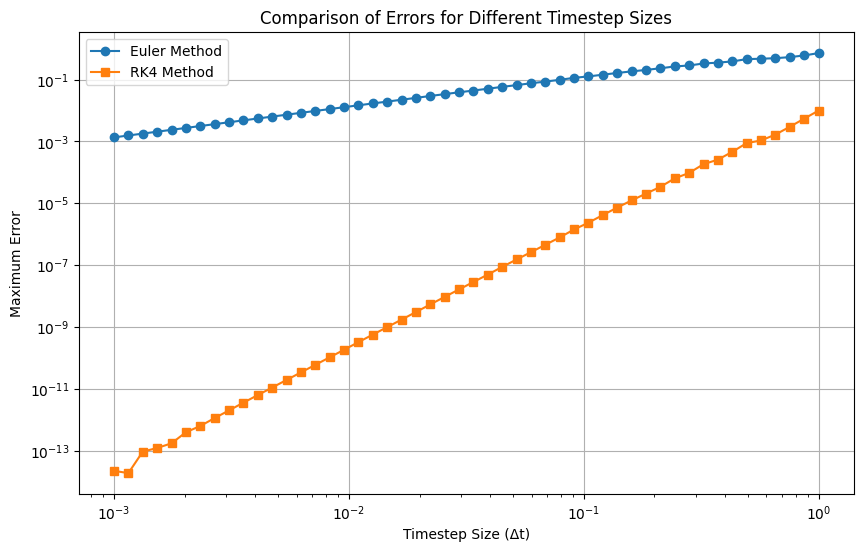

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Euler method
def euler_step(f, x, t, dt):
    """
    Perform a single Euler step.

    Args:
    f: function representing the ODE system.
    x: current state.
    t: current time.
    dt: timestep size.

    Returns:
    The state at the next time step.
    """
    return x + dt * f(x, t)

# Solve to a specific time using Euler's method
def solve_to(f, x0, t0, t_max, dt_max):
    """
    Solve the ODE using Euler's method.

    Args:
    f: function representing the ODE system.
    x0: initial state.
    t0: initial time.
    t_max: end time.
    dt_max: maximum timestep size.

    Returns:
    Two arrays: time points and corresponding states.
    """
    t = [t0]
    x = [x0]
    while t[-1] < t_max:
        dt = min(dt_max, t_max - t[-1])
        x.append(euler_step(f, x[-1], t[-1], dt))
        t.append(t[-1] + dt)
    return np.array(t), np.array(x)

# 4th-order Runge-Kutta method
def rk4_step(f, x, t, dt):
    """
    Perform a single RK4 step.

    Args:
    f: function representing the ODE system.
    x: current state.
    t: current time.
    dt: timestep size.

    Returns:
    The state at the next time step.
    """
    k1 = dt * f(x, t)
    k2 = dt * f(x + 0.5 * k1, t + 0.5 * dt)
    k3 = dt * f(x + 0.5 * k2, t + 0.5 * dt)
    k4 = dt * f(x + k3, t + dt)
    return x + (k1 + 2 * k2 + 2 * k3 + k4) / 6

# Solve to a specific time using the 4th-order Runge-Kutta method
def rk4_solve(f, x0, t0, t_max, dt_max):
    """
    Solve the ODE using the 4th-order Runge-Kutta method.

    Args:
    f: function representing the ODE system.
    x0: initial state.
    t0: initial time.
    t_max: end time.
    dt_max: maximum timestep size.

    Returns:
    Two arrays: time points and corresponding states.
    """
    t = [t0]
    x = [x0]
    while t[-1] < t_max:
        dt = min(dt_max, t_max - t[-1])
        x.append(rk4_step(f, x[-1], t[-1], dt))
        t.append(t[-1] + dt)
    return np.array(t), np.array(x)

# Define the ODE for part 1: dx/dt = x
def ode_func(x, t):
    return x

# Define the true solution for the ODE
def true_solution(t):
    return np.exp(t)

# Function to compute error
def compute_error(approx, true):
    return np.abs(approx - true)

# Function to compare errors for different timestep sizes
def compare_errors(method, f, x0, t0, t_max, dt_values):
    errors = []
    for dt in dt_values:
        if method == 'euler':
            t, x = solve_to(f, x0, t0, t_max, dt)
        elif method == 'rk4':
            t, x = rk4_solve(f, x0, t0, t_max, dt)
        true_values = true_solution(t)
        error = compute_error(x, true_values)
        errors.append(np.max(error))
    return errors

# Plotting
def plot_errors(dt_values, errors_euler, errors_rk4):
    plt.figure(figsize=(10, 6))
    plt.loglog(dt_values, errors_euler, 'o-', label='Euler Method')
    plt.loglog(dt_values, errors_rk4, 's-', label='RK4 Method')
    plt.xlabel('Timestep Size (Δt)')
    plt.ylabel('Maximum Error')
    plt.title('Comparison of Errors for Different Timestep Sizes')
    plt.legend()
    plt.grid(True)
    plt.show()

# Main function
def main():
    x0 = 1  # Initial condition
    t0 = 0  # Initial time
    t_max = 1  # End time
    dt_values = np.logspace(-3, 0, 50)  # Different timestep sizes

    # Compute errors for Euler method
    errors_euler = compare_errors('euler', ode_func, x0, t0, t_max, dt_values)

    # Compute errors for RK4 method
    errors_rk4 = compare_errors('rk4', ode_func, x0, t0, t_max, dt_values)

    # Plot errors
    plot_errors(dt_values, errors_euler, errors_rk4)

if __name__ == "__main__":
    main()
